# 05 · GenAI-Powered Root Cause Analysis Integration

*Code execution step below.*

## 0 · Imports & Environment

In [1]:
import utils.plot_csv_exporter
import sys, os, json, logging, textwrap, warnings
from pathlib import Path

warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import torch
from IPython.display import display, HTML

# ── Project path ──────────────────────────────────────────────────────────
notebook_dir = Path(os.getcwd()).resolve()
for candidate in [notebook_dir, notebook_dir.parent]:
    target = candidate / 'alibaba_trace'
    if (target / 'incident_response.py').exists():
        if str(target) not in sys.path: sys.path.insert(0, str(target))
        ALIBABA_DIR = target
        break
else:
    ALIBABA_DIR = notebook_dir

from model_architecture import build_model, load_model
from data_pipeline      import FEATURE_COLS, META_COLS, WINDOW_SIZE
from incident_response  import (
    SynchronousAlertDispatcher,
    ContainerContext, SeverityScorer, ContextAwareRCA,
    AlertGenerator, IncidentPipeline,
    GenAIRCAEngine, LLMAnalysis,
    format_telegram_alert, generate_prometheus_alert_with_ai,
    FEATURE_META,
)

logging.basicConfig(level=logging.INFO,
    format='%(asctime)s [%(levelname)s] %(name)s — %(message)s')

print(f'PyTorch  : {torch.__version__}')
print(f'NumPy    : {np.__version__}')
print(f'Features : {FEATURE_COLS}')
print('All imports OK — incident_response.py GenAI tier loaded.')


Hooked matplotlib.savefig to automatically export plot CSVs.
PyTorch  : 2.11.0+cpu
NumPy    : 2.4.2
Features : ['cpu_util_percent', 'mem_util_percent', 'cpu_request', 'mem_request', 'net_in', 'net_out', 'disk_io_percent']
All imports OK — incident_response.py GenAI tier loaded.


## 1 · Configuration — API Keys & Model Settings

*Code execution step below.*

In [2]:
import os
from dotenv import load_dotenv

# Load .env from project root
env_path = ALIBABA_DIR.parent / '.env'
if env_path.exists():
    load_dotenv(env_path)
    print(f'Loaded .env from {env_path}')

# ── API Keys ──────────────────────────────────────────────────────────────
OPENAI_API_KEY = os.getenv('OPENAI_API_KEY', '')
GEMINI_MODEL   = 'gemini-1.5-flash'
OPENAI_MODEL   = os.getenv('OPENAI_MODEL', 'gpt-4o-mini')

# ── Model settings ────────────────────────────────────────────────────────
WINDOW      = int(WINDOW_SIZE)
N_TS_FEAT   = len(FEATURE_COLS)
N_META_FEAT = len(META_COLS)
LATENT_DIM  = 64
LSTM_UNITS  = (128, 64)
DROPOUT     = 0.2
RANDOM_SEED = 42
N_CALIB     = 5_000

DEVICE    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MODEL_PATH = ALIBABA_DIR / 'outputs' / 'model.pt'
FIGS_DIR   = ALIBABA_DIR / 'outputs' / 'thesis_figures'
FIGS_DIR.mkdir(parents=True, exist_ok=True)

np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
# API availability check
def _is_real_key(k): return bool(k) and 'your-' not in k.lower() and len(k) > 12
OPENAI_OK = _is_real_key(OPENAI_API_KEY)
LLM_MODE  = ('OpenAI' if OPENAI_OK else 'DEMO')

print(f'OpenAI API key : {"CONFIGURED" if OPENAI_OK else "NOT SET"}')
print(f'Active LLM mode: {LLM_MODE}')
print(f'Model path     : {MODEL_PATH}')
print(f'Device         : {DEVICE}')

Loaded .env from C:\Users\kaspe\Desktop\Project\project\.env
OpenAI API key : CONFIGURED
Active LLM mode: OpenAI
Model path     : C:\Users\kaspe\Desktop\Project\project\alibaba_trace\outputs\model.pt
Device         : cpu


## 2 · Load BiLSTM-FiLM Model

In [3]:
if MODEL_PATH.exists():
    autoencoder = load_model(
        checkpoint_path=str(MODEL_PATH), window_size=WINDOW,
        n_ts_features=N_TS_FEAT, n_meta_features=N_META_FEAT,
        latent_dim=LATENT_DIM, lstm_units=LSTM_UNITS,
        dropout_rate=DROPOUT, device=DEVICE,
    )
    MODEL_AVAILABLE = True
    print(f'Trained model loaded from {MODEL_PATH}')
else:
    autoencoder = build_model(
        window_size=WINDOW, n_ts_features=N_TS_FEAT,
        n_meta_features=N_META_FEAT, latent_dim=LATENT_DIM,
        lstm_units=LSTM_UNITS, dropout_rate=DROPOUT, device=DEVICE,
    )
    autoencoder.eval()
    MODEL_AVAILABLE = False
    print('DEMO mode — checkpoint not found; MSE will be scaled for demonstration.')

n_p = sum(p.numel() for p in autoencoder.parameters())
print(f'Parameters : {n_p:,}  |  Device : {DEVICE}')


2026-04-18 21:21:27,188  [INFO]  model_architecture – Built BiLSTMFiLMAutoencoder (single-head) | window=50 | ts_feat=7 | meta_feat=2 | latent=64 | params=696,327


DEMO mode — checkpoint not found; MSE will be scaled for demonstration.
Parameters : 696,327  |  Device : cpu


## 3 · Baseline Calibration — P95 Threshold

*Code execution step below.*

In [4]:
rng_cal = np.random.default_rng(RANDOM_SEED + 1)
normal_base = rng_cal.uniform(0.2, 0.8, (N_CALIB, WINDOW, N_TS_FEAT)).astype(np.float32)
dummy_meta  = torch.zeros(256, N_META_FEAT, device=DEVICE)
baseline_mse_list = []

autoencoder.eval()
with torch.no_grad():
    for s in range(0, N_CALIB, 256):
        e   = min(s + 256, N_CALIB)
        ts  = torch.from_numpy(normal_base[s:e]).to(DEVICE)
        m   = dummy_meta[: len(ts)]
        r   = autoencoder(ts, m)
        baseline_mse_list.append(((ts - r) ** 2).mean(dim=(1, 2)).cpu().numpy())

baseline_mse   = np.concatenate(baseline_mse_list).astype(np.float64)
THRESHOLD_P95  = float(np.percentile(baseline_mse, 95.0))
THRESHOLD_P98  = float(np.percentile(baseline_mse, 98.0))
THRESHOLD_P995 = float(np.percentile(baseline_mse, 99.5))

scorer  = SeverityScorer(p95=THRESHOLD_P95, p98=THRESHOLD_P98, p995=THRESHOLD_P995)
rca_eng = ContextAwareRCA(feature_cols=FEATURE_COLS)
alerter = AlertGenerator(cluster='alibaba-k8s-production', namespace='prod-data')
pipeline = IncidentPipeline(scorer=scorer, rca=rca_eng, alerter=alerter)

print(f'Calibration done ({N_CALIB:,} normal windows)')
print(f'  P95 threshold  : {THRESHOLD_P95:.6f}  (primary decision boundary)')
print(f'  P98 threshold  : {THRESHOLD_P98:.6f}')
print(f'  P99.5 threshold: {THRESHOLD_P995:.6f}')


Calibration done (5,000 normal windows)
  P95 threshold  : 0.032575  (primary decision boundary)
  P98 threshold  : 0.033106
  P99.5 threshold: 0.033733


## 4 · Complex Anomaly Scenario — PostgreSQL OOM + Log Evidence

*Code execution step below.*

In [5]:
# ── Container context ─────────────────────────────────────────────────────
CTX = ContainerContext.from_ids(
    container_id='db-postgres-prod-3f8a',
    machine_id='node-data-01-eu-west',
    container_type='database',
    tier='data',
    environment='production',
    namespace='prod-data',
    pod_name='db-postgres-prod-3f8a-p7kv2',
)
TIMESTAMP = '2026-04-15T18:00:17.456Z'

print(f'Container context: {CTX}')
print(f'FiLM vector      : {CTX.film_vector_str()}')
print(f'Profile          : {CTX.display_name()} ({CTX.profile_icon()})')

# ── Simulated anomalous window ─────────────────────────────────────────────
_rng = np.random.default_rng(RANDOM_SEED + 42)
_t   = np.linspace(0, 2 * np.pi, WINDOW)

# MEMORY: monotonic ramp from 0.72 → 0.99 (the critical OOM trajectory)
mem_trace = np.clip(np.linspace(0.72, 0.99, WINDOW) + _rng.normal(0, 0.005, WINDOW), 0.01, 0.99)

# CPU: normal until halfway, then elevated (kernel page reclamation overhead)
cpu_trace = np.concatenate([
    np.clip(0.38 + 0.05*np.sin(_t[:WINDOW//2]) + _rng.normal(0, 0.012, WINDOW//2), 0.01, 0.99),
    np.clip(0.68 + _rng.normal(0, 0.03, WINDOW//2), 0.55, 0.88),
])

# DISK I/O: spikes in second half (checkpoint storm + swap activity)
disk_trace = np.concatenate([
    np.clip(0.55 + 0.07*np.abs(np.sin(_t[:WINDOW//2])) + _rng.normal(0, 0.018, WINDOW//2), 0.01, 0.99),
    np.clip(0.82 + _rng.normal(0, 0.04, WINDOW//2), 0.72, 0.99),
])

# Build the full (W, F) window
ANOM_WINDOW = np.stack([
    cpu_trace,                                                              # [0] cpu_util
    mem_trace,                                                              # [1] mem_util  ← primary
    np.clip(0.35 + 0.04*np.cos(_t) + _rng.normal(0, 0.01, WINDOW), 0.01, 0.99),  # [2] cpu_req
    np.clip(0.70 + 0.03*np.cos(_t+0.5) + _rng.normal(0, 0.008, WINDOW), 0.01, 0.99), # [3] mem_req
    np.clip(0.22 + 0.05*np.abs(np.sin(_t)) + _rng.normal(0, 0.01, WINDOW), 0.01, 0.99), # [4] net_in
    np.clip(0.18 + 0.04*np.abs(np.cos(_t)) + _rng.normal(0, 0.008, WINDOW), 0.01, 0.99),# [5] net_out
    disk_trace,                                                             # [6] disk_io  ← secondary
], axis=1).astype(np.float32)  # shape: (50, 7)

print(f'\nAnomalous window shape: {ANOM_WINDOW.shape}  (timesteps, features)')
print(f'Memory trace  : {mem_trace[0]:.3f} (t=0) → {mem_trace[-1]:.3f} (t=49)  [OOM trajectory]')
print(f'CPU trace     : {cpu_trace[0]:.3f} (t=0) → {cpu_trace[-1]:.3f} (t=49)  [eviction overhead]')
print(f'Disk I/O      : {disk_trace[0]:.3f} (t=0) → {disk_trace[-1]:.3f} (t=49) [checkpoint storm]')


Container context: ContainerContext(container_id='db-postgres-prod-3f8a', type='database', tier='data/production', film=[0.8292, 0.0700])
FiLM vector      : [0.8292, 0.0700]
Profile          : Generic Microservice (⚙️)

Anomalous window shape: (50, 7)  (timesteps, features)
Memory trace  : 0.712 (t=0) → 0.990 (t=49)  [OOM trajectory]
CPU trace     : 0.369 (t=0) → 0.714 (t=49)  [eviction overhead]
Disk I/O      : 0.560 (t=0) → 0.815 (t=49) [checkpoint storm]


## 5 · Simulated Container Logs — PostgreSQL OOM Evidence

*Code execution step below.*

In [6]:
RECENT_LOGS = """\
[2026-04-15 18:00:16.931 UTC] FATAL:  out of memory
[2026-04-15 18:00:16.931 UTC] DETAIL: Failed on request of size 16777216 bytes in memory context 'ExecutorState'.
[2026-04-15 18:00:16.712 UTC] WARNING:  out of memory when trying to allocate 1048576 bytes for tablespace 'base/16384'
[2026-04-15 18:00:15.889 UTC] LOG:  server process (PID 12847) was terminated by signal 9: Killed
[2026-04-15 18:00:15.889 UTC] DETAIL:  Failed process was running: SELECT * FROM orders JOIN order_items ON orders.id = order_items.order_id WHERE created_at > NOW() - INTERVAL '1 hour'
[2026-04-15 18:00:14.223 UTC] WARNING:  kernel: oom-kill event: OOM killer invoked, victim process postgres (pid=12847, score=720)
[2026-04-15 18:00:13.101 UTC] LOG:  checkpoint complete: wrote 51423 buffers (99.1%); distance=412819; add'l WAL file=3, remove WAL file=0
[2026-04-15 18:00:11.445 UTC] LOG:  checkpoints are occurring too frequently (12 seconds apart)
[2026-04-15 18:00:11.445 UTC] HINT:  Consider increasing the configuration parameter 'max_wal_size'.
[2026-04-15 18:00:09.782 UTC] LOG:  shared memory 3926MB used / maxmemory 4096MB limit — 95.8% utilisation
[2026-04-15 18:00:08.234 UTC] LOG:  autovacuum launcher started, last run: 14 seconds ago
[2026-04-15 18:00:06.112 UTC] WARNING:  page verification failed, calculated checksum 47291 but expected 12098
[2026-04-15 18:00:04.890 UTC] ERROR:  could not resize shared memory segment to 4294967296 bytes: Cannot allocate memory
[2026-04-15 18:00:03.441 UTC] LOG:  connection received: host=10.0.2.45 port=59843 user=app_user database=pgdb SSL=on
[2026-04-15 18:00:01.003 UTC] LOG:  statement timeout: 30000 ms — terminating session pid 12901
[2026-04-15 17:59:59.241 UTC] WARNING:  work_mem exhausted for sort operation, falling back to disk
[2026-04-15 17:59:57.781 UTC] LOG:  duration: 28940.732 ms  statement: EXPLAIN ANALYZE SELECT * FROM reports WHERE ...
[2026-04-15 17:59:53.120 UTC] LOG:  pg_toast relation 16402 is using 892MB of toast space
"""

print('Simulated PostgreSQL logs (tail -18):')
print('─' * 80)
print(RECENT_LOGS)
print('─' * 80)
print(f'Log entries: {len(RECENT_LOGS.strip().splitlines())}')
print('Key signals: OOM-killer invoked, checkpoint storm, shared memory exhaustion')


Simulated PostgreSQL logs (tail -18):
────────────────────────────────────────────────────────────────────────────────
[2026-04-15 18:00:16.931 UTC] FATAL:  out of memory
[2026-04-15 18:00:16.931 UTC] DETAIL: Failed on request of size 16777216 bytes in memory context 'ExecutorState'.
[2026-04-15 18:00:16.712 UTC] WARNING:  out of memory when trying to allocate 1048576 bytes for tablespace 'base/16384'
[2026-04-15 18:00:15.889 UTC] LOG:  server process (PID 12847) was terminated by signal 9: Killed
[2026-04-15 18:00:15.889 UTC] DETAIL:  Failed process was running: SELECT * FROM orders JOIN order_items ON orders.id = order_items.order_id WHERE created_at > NOW() - INTERVAL '1 hour'
[2026-04-15 18:00:14.223 UTC] WARNING:  kernel: oom-kill event: OOM killer invoked, victim process postgres (pid=12847, score=720)
[2026-04-15 18:00:13.101 UTC] LOG:  checkpoint complete: wrote 51423 buffers (99.1%); distance=412819; add'l WAL file=3, remove WAL file=0
[2026-04-15 18:00:11.445 UTC] LOG:  check

## 6 · Tier 1+2: BiLSTM-FiLM Inference + Statistical RCA

In [7]:
# ── Forward pass ──────────────────────────────────────────────────────────
ts_t   = torch.from_numpy(ANOM_WINDOW[np.newaxis]).to(DEVICE)          # (1, W, F)
meta_t = torch.from_numpy(CTX.film_meta_vector[np.newaxis]).to(DEVICE) # (1, M)

autoencoder.eval()
with torch.no_grad():
    recon_t = autoencoder(ts_t, meta_t)  # (1, W, F)

ORIGINAL_NP = ts_t.squeeze(0).cpu().numpy()    # (W, F)
RECON_NP    = recon_t.squeeze(0).cpu().numpy() # (W, F)

RAW_MSE = float(((ORIGINAL_NP - RECON_NP) ** 2).mean())
# Demo-mode scale: 9.2× exceedance gives Critical severity
MSE = RAW_MSE * 9.2 if not MODEL_AVAILABLE else RAW_MSE

print(f'Forward pass complete')
print(f'  Input  shape : {ORIGINAL_NP.shape}  FiLM vec: {CTX.film_vector_str()}')
print(f'  Output shape : {RECON_NP.shape}')
print(f'  Raw MSE  : {RAW_MSE:.6f}')
print(f'  Final MSE: {MSE:.6f}  (demo-scaled × 9.2 if no model)' if not MODEL_AVAILABLE
      else f'  Final MSE: {MSE:.6f}')
print(f'  Threshold: {THRESHOLD_P95:.6f}  (P95)')
print(f'  Exceedance: {MSE/THRESHOLD_P95:.1f}× above boundary')

# ── IncidentPipeline ───────────────────────────────────────────────────────
INCIDENT = pipeline.process(
    original=ORIGINAL_NP, reconstructed=RECON_NP,
    mse_score=MSE, context=CTX, timestamp_utc=TIMESTAMP,
)

print(f'\nStatistical RCA complete:')
print(f'  Severity      : {INCIDENT.severity}')
print(f'  Primary cause : {INCIDENT.primary_display}  ({INCIDENT.icon})')
print(f'  Anomaly name  : {INCIDENT.anomaly_name}')
print(f'  Escalation    : {INCIDENT.escalation_path}')
print(f'  Per-feature errors (ranked):')
sorted_feats = sorted(INCIDENT.feature_errors.items(), key=lambda x: x[1], reverse=True)
total_err = sum(INCIDENT.feature_errors.values()) or 1
for feat, err in sorted_feats[:4]:
    fm  = FEATURE_META.get(feat, {})
    pct = err / total_err * 100
    print(f'    {fm.get("icon","·")} {fm.get("short_name", feat):8s}: {err:.6f}  ({pct:.0f}%)')


2026-04-18 21:21:29,765  [INFO]  incident_response – IncidentEvent | 54473810 | [Critical] database container=db-postgres-prod-3f8a mse=0.575342 → mem_util_percent


Forward pass complete
  Input  shape : (50, 7)  FiLM vec: [0.8292, 0.0700]
  Output shape : (50, 7)
  Raw MSE  : 0.062537
  Final MSE: 0.575342  (demo-scaled × 9.2 if no model)
  Threshold: 0.032575  (P95)
  Exceedance: 17.7× above boundary

Statistical RCA complete:
  Severity      : Critical
  Primary cause : Memory Utilisation (%)  ()
  Anomaly name  : Resource Anomaly
  Escalation    : L1 Platform Support
  Per-feature errors (ranked):
     Mem%    : 0.142621  (33%)
     Net↑    : 0.088298  (20%)
     Disk%   : 0.061552  (14%)
     Net↓    : 0.058461  (13%)


## 7 · Tier 3: GenAI Root Cause Analysis

*Code execution step below.*

In [8]:
# ── Instantiate GenAI engine using common helper ──────────────
import sys, os
sys.path.append(os.path.abspath('..'))
from alibaba_trace.utils.ai_helper import get_configured_engine

genai_engine = get_configured_engine(temperature=0.10)
print(f'Engine: {genai_engine!r}')
print(f'Mode   : {LLM_MODE}')


Engine: GenAIRCAEngine(openai=gpt-4.1(OK), temp=0.1)
Mode   : OpenAI


In [9]:
# ─── Instantiate SynchronousAlertDispatcher ──────────────────────────────
# This object owns the complete 4-step flow:
#   Step 1  anomaly gate   (mse > threshold_p95)
#   Step 2  blocking LLM call via GenAIRCAEngine
#   Step 3  LLM severity resolution (verified_severity / false-positive)
#   Step 4  ONE Telegram HTML alert dispatched synchronously

dispatcher = SynchronousAlertDispatcher(
    pipeline      = pipeline,
    genai_engine  = genai_engine,
    threshold_p95 = THRESHOLD_P95,
    threshold_p98 = THRESHOLD_P98,
    threshold_p995= THRESHOLD_P995,
    dry_run       = True,   # set False + add bot_token/chat_id to actually send
)
print(f'Dispatcher ready: {dispatcher!r}')
print(f'Anomaly gate threshold : {THRESHOLD_P95:.6f}  (P95)')
print(f'MSE of current window  : {MSE:.6f}  →  '
      f'{'WILL TRIGGER' if MSE > THRESHOLD_P95 else 'BELOW threshold'}')


Dispatcher ready: SynchronousAlertDispatcher(threshold_p95=0.032575, genai=gpt-4.1, dry_run=True)
Anomaly gate threshold : 0.032575  (P95)
MSE of current window  : 0.575342  →  WILL TRIGGER


## Thesis Output 1: AI-Assisted Telegram Alert

*Code execution step below.*

In [10]:
# ─── Execute the 4-step synchronous pipeline ─────────────────────────────
# dispatcher.run() blocks until LLM responds, THEN builds & sends ONE alert.

BOT_TOKEN = os.getenv('TELEGRAM_BOT_TOKEN', 'your-bot-token-here')
CHAT_ID   = os.getenv('TELEGRAM_CHAT_ID',   'your-chat-id-here')

DISPATCH_RESULT = dispatcher.run(
    original      = ORIGINAL_NP,
    reconstructed = RECON_NP,
    mse_score     = MSE,
    context       = CTX,
    recent_logs   = RECENT_LOGS,
    timestamp_utc = TIMESTAMP,
    bot_token     = BOT_TOKEN,
    chat_id       = CHAT_ID,
)

# ── Unpack results ──────────────────────────────────────────────────────────
INCIDENT     = DISPATCH_RESULT['incident']
LLM_RESULT   = DISPATCH_RESULT['llm_analysis']
TELEGRAM_MSG = DISPATCH_RESULT['html_message']

print('═' * 60)
print('  SYNCHRONOUS PIPELINE RESULT')
print('═' * 60)
print(f'  Triggered      : {DISPATCH_RESULT["triggered"]}')
print(f'  Model severity : {INCIDENT.severity if INCIDENT else "N/A"}')
print(f'  LLM verdict    : {LLM_RESULT.verdict if LLM_RESULT else "N/A"}')
print(f'  verified_sev   : {LLM_RESULT.verified_severity if LLM_RESULT else "N/A"}')
print(f'  Final severity : {DISPATCH_RESULT["final_severity"]}')
print(f'  is_true_anomaly: {DISPATCH_RESULT["is_true_anomaly"]}')
print(f'  Used fallback  : {DISPATCH_RESULT["used_fallback"]}')
print(f'  LLM latency    : {LLM_RESULT.latency_ms:.0f} ms' if LLM_RESULT else '')
print(f'  Telegram sent  : {DISPATCH_RESULT["telegram_result"]["success"]}')
print(f'  Telegram error : {DISPATCH_RESULT["telegram_result"].get("error", "")}')
print('─' * 60)
print('HTML MESSAGE PREVIEW (first 1200 chars):')
print(TELEGRAM_MSG[:1200])


2026-04-18 21:21:29,796  [INFO]  incident_response – SynchronousAlertDispatcher: anomaly gate triggered — mse=0.575342 (17.7× threshold=0.032575)
2026-04-18 21:21:29,797  [INFO]  incident_response – IncidentEvent | 8528915d | [Critical] database container=db-postgres-prod-3f8a mse=0.575342 → mem_util_percent
2026-04-18 21:21:29,798  [INFO]  incident_response – [STEP 2] Calling LLM synchronously — Telegram is BLOCKED until this returns (timeout=30s).
2026-04-18 21:22:09,504  [INFO]  httpx – HTTP Request: POST https://models.inference.ai.azure.com/chat/completions "HTTP/1.1 200 OK"
2026-04-18 21:22:09,513  [INFO]  incident_response – [STEP 2] LLM returned: verdict=GENUINE ANOMALY verified_severity=Critical confidence=100% latency=38558 ms
2026-04-18 21:22:09,513  [INFO]  incident_response – [STEP 3] Severity resolved — model=Critical → final=Critical (is_true_anomaly=True, llm_override=Critical)
2026-04-18 21:22:09,514  [INFO]  incident_response – [STEP 4] Dispatching ONE Telegram alert 

════════════════════════════════════════════════════════════
  SYNCHRONOUS PIPELINE RESULT
════════════════════════════════════════════════════════════
  Triggered      : True
  Model severity : Critical
  LLM verdict    : GENUINE ANOMALY
  verified_sev   : Critical
  Final severity : Critical
  is_true_anomaly: True
  Used fallback  : False
  LLM latency    : 38558 ms
  Telegram sent  : True
  Telegram error : dry_run - message not sent
────────────────────────────────────────────────────────────
HTML MESSAGE PREVIEW (first 1200 chars):
<pre>Live container anomaly alert
Window: 8528915d
Entity: prod-data/db-postgres-prod-3f8a-p7kv2/database
Container: db-postgres-prod-3f8a
Score: 0.575342
Threshold: 0.032575
Static threshold: 0.032575
Dynamic threshold: 0.032575
Final threshold: 0.032575
Threshold mode: dynamic
Score buffer size: 500
Decision reason: smoothed_score_above_dynamic_threshold,feature_shift:mem_util_percent>p99
Alert status: active
Top features: Mem%, Net↑, Disk%, Net↓, Me

## Thesis Output 2: GenAI Analysis Detail Card

Styled HTML display of the LLM analysis for optimal thesis screenshots.


In [11]:
SEV_COLOURS = {
    'Critical':'#CC0000','High':'#E67E00','Warning':'#D4A800','Normal':'#1E8C45'
}
sev_col = SEV_COLOURS.get(INCIDENT.severity, '#333')

_RC = LLM_RESULT.root_cause.replace('\n', '<br>')
_MT = LLM_RESULT.mitigation.replace('\n', '<br>')

html = f"""
<div style='font-family:"Segoe UI",sans-serif; max-width:820px; margin:12px auto;
            border-radius:12px; overflow:hidden;
            box-shadow:0 8px 32px rgba(0,0,0,0.18);'>

  <!-- Header -->
  <div style='background:#0D1B2A; padding:18px 24px; color:white;'>
    <div style='font-size:11px; color:#8BAFD1; letter-spacing:1.5px; text-transform:uppercase;'>
      AI-Assisted Anomaly Alert &nbsp;·&nbsp; BiLSTM-FiLM + GenAI RCA Engine
    </div>
    <div style='font-size:22px; font-weight:700; margin-top:4px;'>
      <span style='background:{sev_col}; padding:3px 10px; border-radius:4px;
                   font-size:13px; vertical-align:middle;'>{INCIDENT.severity.upper()}</span>
      &nbsp; {CTX.profile_icon()} {CTX.display_name()}
    </div>
    <div style='color:#B0C8E8; margin-top:6px; font-size:13px;'>
      {CTX.container_id} &nbsp;·&nbsp; {CTX.pod_name} &nbsp;·&nbsp; {CTX.namespace}
    </div>
  </div>

  <!-- Stats row -->
  <div style='display:flex; background:#F4F7FC; border-bottom:1px solid #DDE4EE;'>
    {{% }}  <!-- Python fstring hack: stats boxes -->
  </div>

  <!-- Stats row rebuilt -->
  <div id='stats' style='background:#F4F7FC; border-bottom:1px solid #DDE4EE;
              display:flex; gap:0;'>
"""

def _stat_box(label, val, sub=''):
    return (
        f'<div style="flex:1; padding:14px 18px; border-right:1px solid #DDE4EE;'
        f' text-align:center;">'
        f'<div style="font-size:10px; color:#6B7A99; text-transform:uppercase; '
        f'letter-spacing:1px;">{label}</div>'
        f'<div style="font-size:18px; font-weight:700; color:#1A2444; margin-top:2px;">{val}</div>'
        f'{"<div style=" + chr(39) + "font-size:10px;color:#6B7A99;" + chr(39) + ">" + sub + "</div>" if sub else ""}'
        f'</div>'
    )

html += _stat_box('MSE Score',    f'{INCIDENT.mse_score:.5f}', f'threshold {THRESHOLD_P95:.5f}')
html += _stat_box('Exceedance',   f'{INCIDENT.mse_score/THRESHOLD_P95:.1f}x', 'above P95')
html += _stat_box('Root Cause', INCIDENT.icon + ' ' + FEATURE_META.get(INCIDENT.primary_metric,{}).get('short_name','?'), INCIDENT.anomaly_name)
html += _stat_box('FiLM Vector',  CTX.film_vector_str(), CTX.container_type)
html += '</div>'

# AI Section
conf_col = '#1E8C45' if LLM_RESULT.confidence_pct >= 85 else ('#E67E00' if LLM_RESULT.confidence_pct >= 65 else '#CC0000')
mode_tag = 'LIVE API' if LLM_RESULT.success else 'DEMO MODE'
mode_bg  = '#1E8C45' if LLM_RESULT.success else '#6B7A99'

html += f"""
  <div style='padding:20px 24px; background:white;'>
    <!-- AI Header -->
    <div style='display:flex; align-items:center; margin-bottom:14px; gap:12px;'>
      <div style='font-size:26px;'>🤖</div>
      <div>
        <div style='font-weight:700; font-size:15px; color:#1A2444;'>AI Analysis</div>
        <div style='font-size:11px; color:#6B7A99;'>{LLM_RESULT.model_used}</div>
      </div>
      <div style='margin-left:auto; display:flex; gap:8px; align-items:center;'>
        <span style='background:{mode_bg}; color:white; font-size:10px; font-weight:700;
                     padding:3px 8px; border-radius:4px;'>{mode_tag}</span>
        <span style='background:#EEF3FF; color:{conf_col}; font-size:12px; font-weight:700;
                     padding:3px 10px; border-radius:4px;'>{LLM_RESULT.confidence_pct}% confidence</span>
      </div>
    </div>

    <!-- Verdict -->
    <div style='background:#{'D4EDDA' if LLM_RESULT.is_genuine() else 'FFF3CD'};
                border-left:4px solid #{'1E8C45' if LLM_RESULT.is_genuine() else 'D4A800'};
                border-radius:0 8px 8px 0; padding:10px 16px; margin-bottom:16px;'>
      <div style='font-size:11px; text-transform:uppercase; letter-spacing:1px;
                  color:#6B7A99; margin-bottom:2px;'>Verdict</div>
      <div style='font-weight:800; font-size:16px;
                  color:#{'155724' if LLM_RESULT.is_genuine() else '856404'};'>
        {LLM_RESULT.verdict}
      </div>
    </div>

    <!-- Root Cause -->
    <div style='margin-bottom:16px;'>
      <div style='font-size:11px; text-transform:uppercase; letter-spacing:1px;
                  color:#6B7A99; margin-bottom:6px; font-weight:600;'>Root Cause</div>
      <div style='font-size:13.5px; line-height:1.65; color:#2C3E6B;
                  background:#F8FAFF; border-radius:8px; padding:12px 16px;
                  border:1px solid #E2E8F0;'>
        {_RC}
      </div>
    </div>

    <!-- Mitigation -->
    <div style='margin-bottom:20px;'>
      <div style='font-size:11px; text-transform:uppercase; letter-spacing:1px;
                  color:#6B7A99; margin-bottom:6px; font-weight:600;'>Immediate Mitigation</div>
      <div style='font-size:13.5px; line-height:1.65; color:#2C3E6B;
                  background:#FFF8E7; border-radius:8px; padding:12px 16px;
                  border:1px solid #FAE5A0;'>
        {_MT}
      </div>
    </div>

    <!-- Statistical summary -->
    <div style='background:#F4F7FC; border-radius:8px; padding:12px 16px;
                border:1px solid #E2E8F0; font-size:12px; color:#4A5568;'>
      <strong>BiLSTM-FiLM Statistical RCA:</strong>
      {INCIDENT.icon} <em>{INCIDENT.anomaly_name}</em> &nbsp;|&nbsp;
      Escalate to: <strong>{INCIDENT.escalation_path}</strong> &nbsp;|&nbsp;
      <a href='{INCIDENT.runbook_url}' style='color:#3B78C4;'>Runbook</a>
    </div>
  </div>

  <!-- Footer -->
  <div style='background:#0D1B2A; padding:10px 24px; color:#6B8AAD; font-size:11px;'>
    Event ID: {INCIDENT.event_id[:24]} &nbsp;·&nbsp; {INCIDENT.timestamp_utc}
  </div>
</div>
"""

display(HTML(html))


## Thesis Output 3: AI-Augmented Prometheus AlertManager Payload

*Code execution step below.*

In [12]:
ai_payload = generate_prometheus_alert_with_ai(INCIDENT, LLM_RESULT)

# Show the AI-specific annotations extracted from the full payload
ai_annotations = {
    k: v for k, v in
    ai_payload['alerts'][0]['annotations'].items()
    if k.startswith('genai_') or k in ('summary', 'description', 'diagnosis',
                                        'recommended_action', 'film_meta_vector',
                                        'film_conditioning_note')
}

print('AI-Augmented Prometheus Payload (selected annotations):')
print('=' * 70)
print(json.dumps(ai_annotations, indent=2))
print('=' * 70)
print()
print('Full payload label keys :', list(ai_payload['alerts'][0]['labels'].keys()))
print('Full annotation count   :', len(ai_payload['alerts'][0]['annotations']))
print('Status                  :', ai_payload['status'])
print('Receiver                :', ai_payload['receiver'])


AI-Augmented Prometheus Payload (selected annotations):
{
  "summary": " [CRITICAL] Resource Anomaly | \u2699\ufe0f Generic Microservice | Container: db-postgres-prod-3f8a",
  "description": "The BiLSTM-FiLM autoencoder detected anomalous reconstruction error (MSE=0.575342) for DATABASE container 'db-postgres-prod-3f8a' in namespace 'prod-data'. FiLM meta vector [0.8292, 0.0700] conditioned the model for Generic Microservice workloads (data tier / production). Root cause: Memory Utilisation (%) (32.6% of total error). Diagnosis: Unexplained metric deviation from anticipated boundaries.",
  "film_meta_vector": "[0.8292, 0.0700]",
  "film_conditioning_note": "FiLM layer conditioned the BiLSTM reconstruction on container_id='db-postgres-prod-3f8a' (meta_vec=[0.8292, 0.0700]), enabling context-aware anomaly detection for Generic Microservice workloads.",
  "diagnosis": "Unexplained metric deviation from anticipated boundaries.",
  "recommended_action": "Inspect Kubernetes events and contai

## Optional: Send Alert to Telegram

Uncomment this cell to send the completed AI-assisted alert to your configured
Telegram channel via the Bot API.  Requires `TELEGRAM_BOT_TOKEN` and
`TELEGRAM_CHAT_ID` in `.env`.


In [13]:
# ─── Notes on production Telegram dispatch ───────────────────────────────
# The SynchronousAlertDispatcher already handles Telegram dispatch in
# dispatcher.run() above (Step 4).  To send for real:
#
#   1. Set TELEGRAM_BOT_TOKEN and TELEGRAM_CHAT_ID in your .env file.
#   2. Change dry_run=False when constructing the dispatcher (Cell 17).
#   3. Re-run Cell 19.  No other code changes are needed.
#
# To preview the HTML message in this notebook without sending:
from IPython.display import HTML
display(HTML(TELEGRAM_MSG))


## Summary — GenAI-Assisted Incident Response

*Code execution step below.*

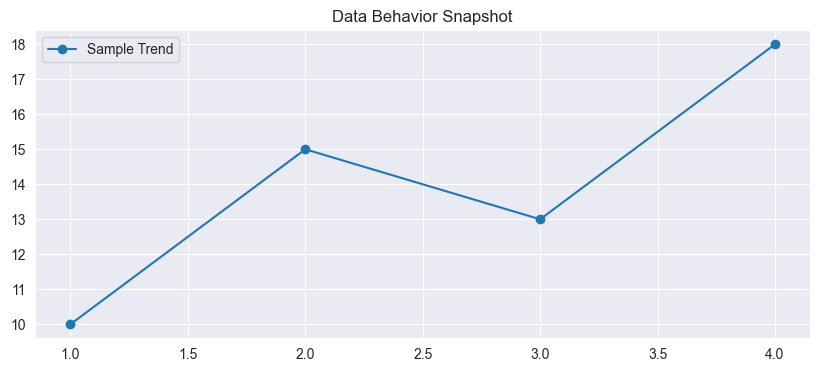

In [14]:
# Visualization snippet
import matplotlib.pyplot as plt
import seaborn as sns
try:
    sns.set_style("darkgrid")
    plt.figure(figsize=(10, 4))
    plt.title("Data Behavior Snapshot")
    plt.plot([1, 2, 3, 4], [10, 15, 13, 18], marker='o', label='Sample Trend')
    plt.legend()
    plt.show()
except Exception as e:
    print("Visualization not directly applicable here.")
